In [1]:
import os, sys, pickle
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', message=".*timestamp seems very low.*")

# ── project paths ──────────────────────────────────────────────────────
REPO_ROOT = '/Users/ariannaarmanetti/Desktop/CODES/inverse-spin/'

import qspin
from qspin.data import load_data
from qspin.gauge import gaugefixing_data
from qspin.inference_pcd import (
    # persistent contrastive divergence inference
    generalizedIsing_inferencePCD, 
    generalizedBC_inferencePCD, 
    generalizedBEG_inferencePCD
)
from qspin.inference import (
    # pseudo-likelihood inference
    generalizedIsing_inference,
    generalizedBC_inference,
    generalizedBEG_inference,
)
from qspin.mcmc import (
    # MCMC wrappers
    mcmc_ising,
    mcmc_beg,
)
from qspin.sampling import (
    # sampling
    sample_configurations_likelearning,
)
from qspin.nullmodels import (energy,
    catind_model, null_gaussian_copula, model_gaussdisc)

%load_ext autoreload
%autoreload 2


In [13]:
# GENERAL SETTINGS AND PARAMETERS
# -------------------------------------------------------
#DATASETS_LIST = ['big5','cfcs', 'dass', 'ei',  
#                 'gcbs', 'hsns', 'iri', 'mach',
#                 'pwe', 'rwas', 'sd3'] # 'acme','hexaco','msscq',
DATASETS_LIST = ['big5']  # for quick testing
NMAX = 10000

# *** PATHS TO CONFIGURE ***
PATHDATA = "/Users/ariannaarmanetti/Desktop/CODES/datasets/"
LEARNINGPATH  = REPO_ROOT + 'learning/'
SAVEPATH = "/Users/ariannaarmanetti/Desktop/CODES/inverse-spin/stability/"
# **************************

os.makedirs(SAVEPATH, exist_ok=True)


BETA_IN   = 0.
BETA_F    = 1.
NSWEEPS   = 1000
IICC      = 'random'
NB_CHUNKS = 100

# -------------------------------------------------------
n_intersample_sweeps = 1000
reset = 'emp'  # 'emp' or 'rand'

# -------------------------------------------------------
TRAIN_FRAC = 0.8
# PSEUDO-LIKELIHOOD LEARNING
L2_LAMBDA          = 1.0E-2
NITERATIONS_PSELIK = 1000
L_RATES_PSELIK     = 1.0E-7
# -------------------------------------------------------
# FULL-LIKELIHOOD LEARNING — Ising and BC share the same schedule
OPTIMIZER = 'adam'  # 'adam' or 'sgd'
NITERATIONS_ISING = [120, 120, 120]
L_RATES_ISING     = [1.0E-3, 1.0E-3, 1.0E-4]
TAU_PCD_ISING     = 100
TAU_THERM_ISING   = 10
NCOPIES_ISING     = [100, 1000, 1000]

NITERATIONS_BEG = [20, 120, 120, 120]
L_RATES_BEG     = [1.0E-4, 1.0E-4, 1.0E-4, 1.0E-5]
TAU_PCD_BEG     = 100
TAU_THERM_BEG   = 100
NCOPIES_BEG     = [10, 100, 1000, 1000]
N_WORKERS       = 15

In [44]:
# ─────────────────────────────────────────────────────────────────────────────
# DATA LOADING AND PREPROCESSING
# Popola DATA[dataset] con tutti gli array necessari alle figure.
# Esegui questa cella una volta; poi ogni cella di figura è indipendente.
# ─────────────────────────────────────────────────────────────────────────────
DATA = {}
SEP  = '=' * 60


for DATASET in DATASETS_LIST:
    print(f'\n{SEP}\nProcessing: {DATASET}\n{SEP}')

    d = {}                        # dizionario per questo dataset
    learningpath = os.path.join(LEARNINGPATH, DATASET+'-cd')
    savepath = os.path.join(SAVEPATH, DATASET)
    d['savepath'] = savepath
    os.makedirs(d['savepath'], exist_ok=True)

    # ── raw data ──────────────────────────────────────────────────────────────
    data_dict = np.load(os.path.join(learningpath, 'data.npz'))
    X   = data_dict['Xtrain']
    Xte = data_dict['Xtest']
    N, M = X.shape
    values = np.unique(X)
    R = len(values)
    d['X'], d['Xte'], d['N'], d['M'], d['R'] = X, Xte, N, M, R
    print(f'  N={N}  M={M}  R={R}')

    def _load(fname):
        with open(os.path.join(learningpath, fname), 'rb') as fh:
            return pickle.load(fh)


    # ── learned models ────────────────────────────────────────────────────────
    d['inverseisingPCD'] = _load('inverseising_cd.pickle')
    d['inversebcPCD']    = _load('inversebc_cd.pickle')
    d['inversebegPCD']   = _load('inversebeg_cd.pickle')

    # ── simulation dictionaries ───────────────────────────────────────────────
    d['sim_dict_list_ising'] = _load('sim_dict_list_ising_cd.pickle')
    d['sim_dict_list_bc']    = _load('sim_dict_list_bc_cd.pickle')
    d['sim_dict_list_beg']   = _load('sim_dict_list_beg_cd.pickle')
    
    DATA[DATASET] = d

print('\nDone. Datasets in DATA:', list(DATA.keys()))



Processing: big5
  N=8000  M=50  R=5

Done. Datasets in DATA: ['big5']


In [ ]:
# load the learned models and simulation dictionaries for the current dataset
inverseisingPCD = d['inverseisingPCD']
inversebcPCD    = d['inversebcPCD']
inversebegPCD   = d['inversebegPCD']

sim_dict_list_ising = d['sim_dict_list_ising']
sim_dict_list_bc    = d['sim_dict_list_bc']
sim_dict_list_beg   = d['sim_dict_list_beg']

states = inverseisingPCD.states
JstarIsingCD, hstarIsingCD             = inverseisingPCD.J_fit, inverseisingPCD.h_fit
JstarBCCD,    hstarBCCD                = inversebcPCD.J_fit,    inversebcPCD.h_fit
JstarBEGCD,   hstarBEGCD, KstarBEGCD   = inversebegPCD.J_fit,   inversebegPCD.h_fit, inversebegPCD.K_fit


In [14]:
# load a sampled dataset of the same size as the original one, using the learned model
# if it does not exist, sample it and save it to disk
if os.path.isfile(os.path.join(savepath, 'dataising.npz')):
    dataising = np.load(os.path.join(savepath, 'dataising.npz'))
    Xtrain_Ising = dataising['Xtrain']
    Xtest_Ising = dataising['Xtest']

    databc = np.load(os.path.join(savepath, 'databc.npz'))
    Xtrain_BC = databc['Xtrain']
    Xtest_BC = databc['Xtest']

    databeg = np.load(os.path.join(savepath, 'databeg.npz'))
    Xtrain_BEG = databeg['Xtrain']
    Xtest_BEG = databeg['Xtest']

else:
    # 1. initialize and thermalize MCMC samplers for each model
    mcmc_ising_pcd = mcmc_ising(JstarIsingCD, hstarIsingCD, R)
    mcmc_ising_pcd.thermalize(betai=BETA_IN, betaf=BETA_F, nsweeps=NSWEEPS,
                                iicc=IICC, nb_chunks=NB_CHUNKS, verbose=True)

    mcmc_bc_pcd = mcmc_ising(JstarBCCD, hstarBCCD, R, anisotropy=True)
    mcmc_bc_pcd.thermalize(betai=BETA_IN, betaf=BETA_F, nsweeps=NSWEEPS,
                            iicc=IICC, nb_chunks=NB_CHUNKS, verbose=True)

    mcmc_beg_pcd = mcmc_beg(JstarBEGCD, hstarBEGCD, KstarBEGCD, R)
    mcmc_beg_pcd.thermalize(betai=BETA_IN, betaf=BETA_F, nsweeps=NSWEEPS,
                                iicc=IICC, nb_chunks=NB_CHUNKS, verbose=True)
    
    # 2. sample MCMC for Ising
    sample_Ising = sample_configurations_likelearning(
                mcmc_ising_pcd,
                X=X,
                states=states,
                N_configurations=N*n_intersample_sweeps,
                n_intersample_sweeps=n_intersample_sweeps,
                reset=reset,
                pseudolikelihood=False,
                verbose=True,
                n_jobs=10)

    # keep only N configuration, one every 100, to avoid correlations
    configs_ising = sample_Ising['configurations']

    Xsample_Ising = configs_ising[::n_intersample_sweeps]
    Xsample_Ising.shape

    # 3. sample MCMC for BC
    sample_BC = sample_configurations_likelearning(
                mcmc_bc_pcd,
                X=X,
                states=states,
                N_configurations=N*n_intersample_sweeps,
                n_intersample_sweeps=n_intersample_sweeps,
                reset=reset,
                pseudolikelihood=False,
                verbose=True,
                n_jobs=10)

    # keep only N configuration, one every 100, to avoid correlations
    configs_bc = sample_BC['configurations']

    Xsample_BC = configs_bc[::n_intersample_sweeps]
    Xsample_BC.shape

    # 4. sample MCMC for BEG
    sample_BEG = sample_configurations_likelearning(
                mcmc_beg_pcd,
                X=X,
                states=states,
                N_configurations=N*n_intersample_sweeps,
                n_intersample_sweeps=n_intersample_sweeps,
                reset=reset,
                pseudolikelihood=False,
                verbose=True,
                n_jobs=10)

    # keep only N configuration, one every 100, to avoid correlations
    configs_beg = sample_BEG['configurations']

    Xsample_BEG = configs_beg[::n_intersample_sweeps]
    Xsample_BEG.shape

    # 5. split into train and test sets
    Neffective = min(N, NMAX)
    idx = np.arange(N)
    np.random.shuffle(idx)
    idx = idx[:Neffective]
    Ntrain = int(TRAIN_FRAC * Neffective)
    Ntest  = Neffective - Ntrain
    Xtrain_Ising = Xsample_Ising[idx[:Ntrain], :]
    Xtest_Ising  = Xsample_Ising[idx[Ntrain:Ntrain + Ntest], :]

    Xtrain_BC = Xsample_BC[idx[:Ntrain], :]
    Xtest_BC  = Xsample_BC[idx[Ntrain:Ntrain + Ntest], :]

    Xtrain_BEG = Xsample_BEG[idx[:Ntrain], :]
    Xtest_BEG  = Xsample_BEG[idx[Ntrain:Ntrain + Ntest], :]

    np.savez(savepath + '/dataising.npz', Xtrain=Xtrain_Ising, Xtest=Xtest_Ising)
    np.savez(savepath + '/databc.npz', Xtrain=Xtrain_BC, Xtest=Xtest_BC)
    np.savez(savepath + '/databeg.npz', Xtrain=Xtrain_BEG, Xtest=Xtest_BEG)


In [15]:
# compute the moments of the sampled configurations and compare with the original ones
# possible only if sampled now, not with loaded sampled data
if 'Xsample_Ising' in locals() and 'Xsample_BC' in locals() and 'Xsample_BEG' in locals():
    avgsamp_Ising = np.mean(Xsample_Ising, axis=0)
    stdsamp_Ising = np.std(Xsample_Ising, axis=0)

    avgsamp_BC    = np.mean(Xsample_BC, axis=0)
    stdsamp_BC    = np.std(Xsample_BC, axis=0)

    avgsamp_BEG   = np.mean(Xsample_BEG, axis=0)
    stdsamp_BEG   = np.std(Xsample_BEG, axis=0)

    avg_emp = np.mean(X, axis=0)
    std_emp = np.std(X, axis=0)

    plt.figure(figsize=(10,6))
    items = np.arange(len(avg_emp))
    plt.errorbar(items,avg_emp, yerr=std_emp, fmt='o', color='black', label='empirical')
    plt.errorbar(items,avgsamp_Ising, yerr=stdsamp_Ising, fmt='o', color='orange', label='Ising', alpha=0.7)
    plt.errorbar(items,avgsamp_BC, yerr=stdsamp_BC, fmt='o', color='blue', label='BC', alpha=0.7)
    plt.errorbar(items,avgsamp_BEG, yerr=stdsamp_BEG, fmt='o', color='brown', label='BEG', alpha=0.7)
    plt.xlabel('item index')
    plt.ylabel('average value')   
    plt.legend()
    
else: 
    print("Sampled data not available, skipping moment comparison.")

Sampled data not available, skipping moment comparison.


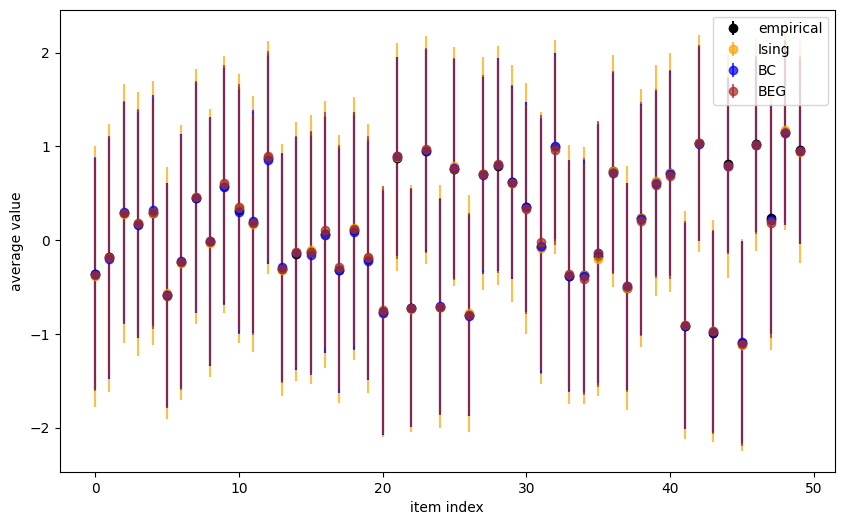

In [10]:
plt.figure(figsize=(10,6))
items = np.arange(len(avg_emp))
plt.errorbar(items,avg_emp, yerr=std_emp, fmt='o', color='black', label='empirical')
plt.errorbar(items,avgsamp_Ising, yerr=stdsamp_Ising, fmt='o', color='orange', label='Ising', alpha=0.7)
plt.errorbar(items,avgsamp_BC, yerr=stdsamp_BC, fmt='o', color='blue', label='BC', alpha=0.7)
plt.errorbar(items,avgsamp_BEG, yerr=stdsamp_BEG, fmt='o', color='brown', label='BEG', alpha=0.7)
plt.xlabel('item index')
plt.ylabel('average value')   
plt.legend()

In [19]:
os.path.isfile(savepath + '/' + 'inverseising' + '.pickle')
with open(savepath + '/' + 'inverseising' + '.pickle', 'rb') as fh:
    inverseising_sample = pickle.load(fh)

In [20]:
if os.path.isfile(savepath + '/' + 'inverseising' + '.pickle'):
    with open(savepath + '/' + 'inverseising' + '.pickle', 'rb') as fh:
        inverseising_sample = pickle.load(fh)
    with open(savepath + '/' + 'inversebc' + '.pickle', 'rb') as fh:
        inversebc_sample = pickle.load(fh)
    with open(savepath + '/' + 'inversebeg' + '.pickle', 'rb') as fh:
        inversebeg_sample = pickle.load(fh)
    with open(savepath + '/' + 'inverseising_cd' + '.pickle', 'rb') as fh:
        inverseisingPCD_sample = pickle.load(fh)
    with open(savepath + '/' + 'inversebc_cd' + '.pickle', 'rb') as fh:
        inversebcPCD_sample = pickle.load(fh)
    with open(savepath + '/' + 'inversebeg_cd' + '.pickle', 'rb') as fh:
        inversebegPCD_sample = pickle.load(fh)

else:
    print("Pickle files not found. Running the learning code first to generate them.")

    # PL learning
    inverseising_sample = generalizedIsing_inference(Q=R, l2_lambda=L2_LAMBDA)
    JstarIsing_sample, hstarIsing_sample = inverseising_sample.fit(Xtrain_Ising)

    inversebc_sample = generalizedBC_inference(Q=R, l2_lambda=L2_LAMBDA)
    JstarBC_sample, hstarBC_sample = inversebc_sample.fit(Xtrain_BC, iicc='meanfield')
            
    inversebeg_sample = generalizedBEG_inference(Q=R, l2_lambda=L2_LAMBDA)
    JstarBEG_sample, hstarBEG_sample, KstarBEG_sample = inversebeg_sample.fit(Xtrain_BEG)

    # PCD learning
    # --- Ising PCD ---
    print('PCD Ising | starting')
    inverseisingPCD_sample = generalizedIsing_inferencePCD(Q=R, l2_lambda=0.)
    J0, h0 = JstarIsing_sample, hstarIsing_sample          # warm start from PL for block 0
    losses_isingcd_blocks = []
    n_blocks = len(NITERATIONS_ISING)
    for i in range(n_blocks):
        print(f'PCD Ising | block {i+1}/{n_blocks}  '
                f'ncopies={NCOPIES_ISING[i]}  niter={NITERATIONS_ISING[i]}  lr={L_RATES_ISING[i]}')
        J0, h0 = inverseisingPCD_sample.fit(
            np.copy(Xtrain_Ising),
            optimizer=OPTIMIZER,
            niterations=NITERATIONS_ISING[i],
            learning_rate=L_RATES_ISING[i],
            tau_PCD=TAU_PCD_ISING,
            tau_therm=TAU_THERM_ISING,
            ncopies=NCOPIES_ISING[i],
            iicc='given',
            J0=J0,
            h0=h0,
            verbose=False,
            n_workers=N_WORKERS)  
        losses_isingcd_blocks.append(np.copy(inverseisingPCD_sample.losses))
    losses_isingcd = np.concatenate(losses_isingcd_blocks)

    # --- BC PCD ---
    print('PCD BC | starting')
    inversebcPCD_sample = generalizedBC_inferencePCD(Q=R, l2_lambda=0.)
    J0, h0 = JstarBC_sample, hstarBC_sample
    losses_bccd_blocks = []
    for i in range(n_blocks):
        print(f'PCD BC | block {i+1}/{n_blocks}  '
                f'ncopies={NCOPIES_ISING[i]}  niter={NITERATIONS_ISING[i]}  lr={L_RATES_ISING[i]}')
        J0, h0 = inversebcPCD_sample.fit(
            np.copy(Xtrain_BC),
            optimizer=OPTIMIZER,
            niterations=NITERATIONS_ISING[i],
            learning_rate=L_RATES_ISING[i],
            tau_PCD=TAU_PCD_ISING,
            tau_therm=TAU_THERM_ISING,
            ncopies=NCOPIES_ISING[i],
            iicc='given',
            J0=J0,
            h0=h0,
            verbose=False,
            n_workers=N_WORKERS)
        losses_bccd_blocks.append(np.copy(inversebcPCD_sample.losses))
    losses_bccd = np.concatenate(losses_bccd_blocks)
    print('PCD BC | done')

    # --- BEG PCD ---
    print('PCD BEG | starting')
    inversebegPCD_sample = generalizedBEG_inferencePCD(Q=R, l2_lambda=0.)
    J0, h0, K0 = JstarBEG_sample, hstarBEG_sample, KstarBEG_sample
    losses_begcd_blocks = []
    n_blocks_beg = len(NITERATIONS_BEG)
    for i in range(n_blocks_beg):
        print(f'PCD BEG | block {i+1}/{n_blocks_beg}  '
                f'ncopies={NCOPIES_BEG[i]}  niter={NITERATIONS_BEG[i]}  lr={L_RATES_BEG[i]}')
        J0, h0, K0 = inversebegPCD_sample.fit(
            np.copy(Xtrain_BEG),
            optimizer=OPTIMIZER,
            niterations=NITERATIONS_BEG[i],
            learning_rate=L_RATES_BEG[i],
            tau_PCD=TAU_PCD_BEG,
            tau_therm=TAU_THERM_BEG,
            ncopies=NCOPIES_BEG[i],
            iicc='given',
            J0=J0,
            h0=h0,
            K0=K0,
            verbose=False,
            n_workers=N_WORKERS)
        losses_begcd_blocks.append(np.copy(inversebegPCD_sample.losses))
    losses_begcd = np.concatenate(losses_begcd_blocks)
    print('PCD BEG | done')

    for fname, obj in [('inverseising',    inverseising_sample),
                        ('inversebc',       inversebc_sample),
                        ('inversebeg',      inversebeg_sample),
                        ('inverseising_cd', inverseisingPCD_sample),
                        ('inversebc_cd',    inversebcPCD_sample),
                        ('inversebeg_cd',   inversebegPCD_sample)]:
            with open(savepath + '/' + fname + '.pickle', 'wb') as f:
                pickle.dump(obj, f, protocol=pickle.HIGHEST_PROTOCOL)

In [21]:
JstarIsingCD_sample, hstarIsingCD_sample             = inverseisingPCD_sample.J_fit, inverseisingPCD_sample.h_fit
JstarBCCD_sample,    hstarBCCD_sample                = inversebcPCD_sample.J_fit,    inversebcPCD_sample.h_fit
JstarBEGCD_sample,   hstarBEGCD_sample, KstarBEGCD_sample   = inversebegPCD_sample.J_fit,   inversebegPCD_sample.h_fit, inversebegPCD_sample.K_fit


In [22]:
# colour palette
COLORS = dict(
    emp       = 'dimgrey',    # dark grey 
    ising     = '#E69F00',  # arancio (alta luminanza)
    bc        = '#56B4E9',  # blu cielo (luminanza media)
    beg       = 'brown',  #'#009E73',  # verde bluastro (scuro)
    gauss     = '#CC79A7',  # viola rossastro (medio)
    gaussdisc = '#D55E00',  # vermiglio (arancio scuro)
    nullcat   = '#0072B2',  # blu scuro 
    copula    = '#F0E442',  # giallo (OK con histtype='step' su sfondo bianco)
)

# plot configuration
CFG = dict(
    nbins_E2d      = 80,    # bins for Euclidean-distance histogram (model curves)
    nbins_energy   = 80,    # bins for Mahalanobis histogram (model curves)
    nbins_pc       = 60,    # bins for PC / factor histograms (model curves)
    nbins_emp      = 20,    # bins for the empirical bar
    mypvalue       = 0.05,  # Wilson CI confidence level
    alpha_emp      = 0.1,   # transparency of empirical histogram fill
    xlabel_fsize   = 15,
    suptitle_fsize = 16,
    nb_items       = 12,    # items shown in item histogram
    item_ncols     = 4,
)

matplotlib.rcParams['pdf.fonttype'] = 42   # editable text in PDFs
matplotlib.rcParams['ps.fonttype']  = 42


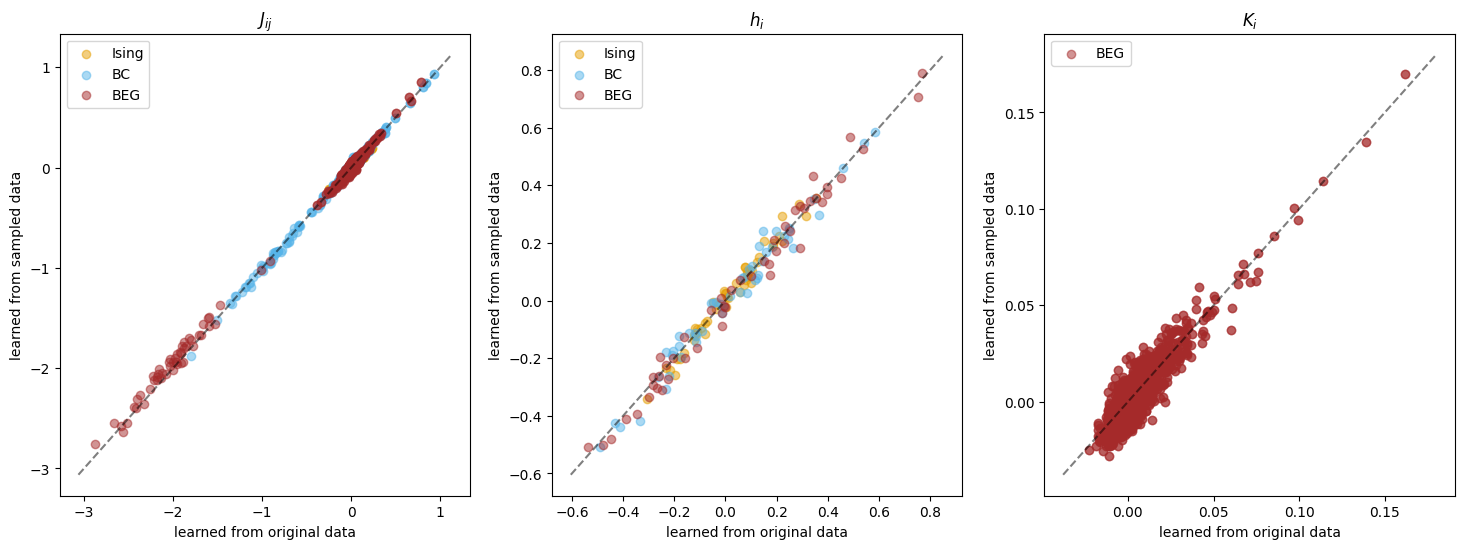

In [23]:
# scatter plots of the learned parameters from sampled data 
# vs learned from the original data

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.scatter(JstarIsingCD.flatten(), JstarIsingCD_sample.flatten(), alpha=0.5, color=COLORS['ising'], label='Ising')
plt.scatter(JstarBCCD.flatten(), JstarBCCD_sample.flatten(), alpha=0.5, color=COLORS['bc'], label='BC')
plt.scatter(JstarBEGCD.flatten(), JstarBEGCD_sample.flatten(), alpha=0.5, color=COLORS['beg'], label='BEG')
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
lims = [min(xmin, ymin), max(xmax, ymax)]
plt.plot(lims, lims, 'k--', alpha=0.5)
plt.xlabel('learned from original data')
plt.ylabel('learned from sampled data')
plt.title(r'$J_{ij}$')
plt.legend()

plt.subplot(1,3,2)
plt.scatter(hstarIsingCD.flatten(), hstarIsingCD_sample.flatten(), alpha=0.5, color=COLORS['ising'], label='Ising')
plt.scatter(hstarBCCD.flatten(), hstarBCCD_sample.flatten(), alpha=0.5, color=COLORS['bc'], label='BC')
plt.scatter(hstarBEGCD.flatten(), hstarBEGCD_sample.flatten(), alpha=0.5, color=COLORS['beg'], label='BEG')
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
lims = [min(xmin, ymin), max(xmax, ymax)]
plt.plot(lims, lims, 'k--', alpha=0.5)
plt.xlabel('learned from original data')
plt.ylabel('learned from sampled data')
plt.title(r'$h_i$')
plt.legend()

plt.subplot(1,3,3)
plt.scatter(KstarBEGCD.flatten(), KstarBEGCD_sample.flatten(), alpha=0.5, color=COLORS['beg'], label='BEG')
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
lims = [min(xmin, ymin), max(xmax, ymax)]
plt.plot(lims, lims, 'k--', alpha=0.5)
plt.xlabel('learned from original data')
plt.ylabel('learned from sampled data')
plt.title(r'$K_i$')
plt.legend()

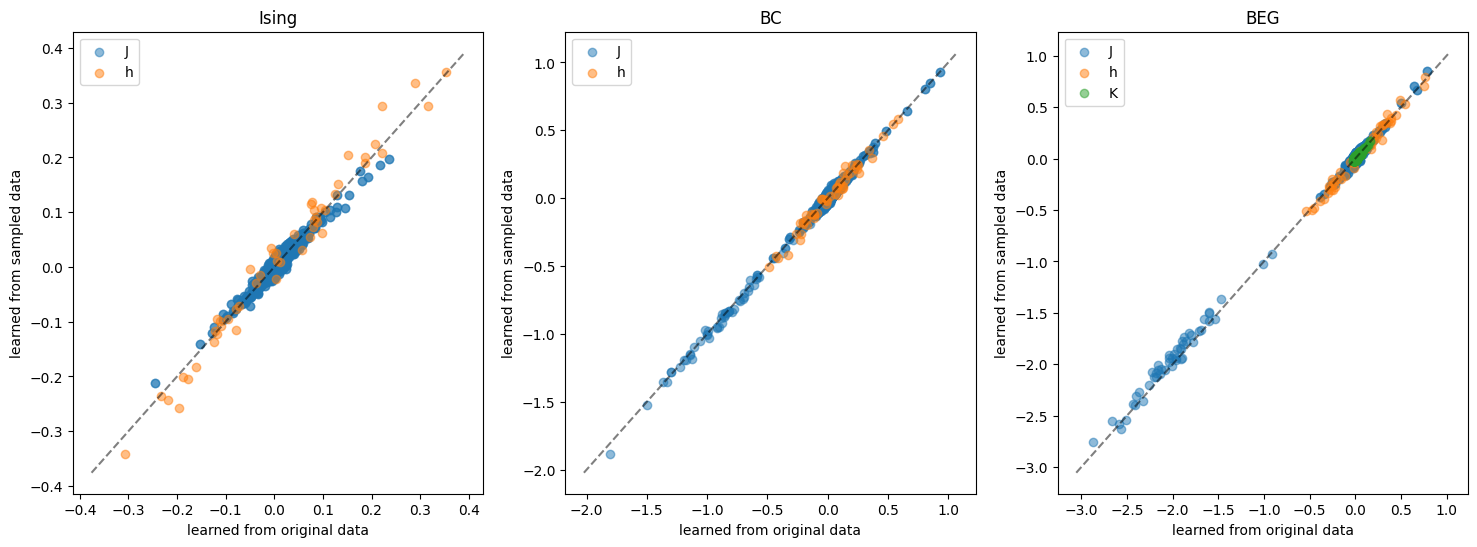

In [24]:
# scatter plots of the learned parameters from sampled data 
# vs learned from the original data

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.scatter(JstarIsingCD.flatten(), JstarIsingCD_sample.flatten(), alpha=0.5, label='J')
plt.scatter(hstarIsingCD.flatten(), hstarIsingCD_sample.flatten(), alpha=0.5, label='h')
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
minx = min(xmin, ymin)
maxx = max(xmax, ymax)
plt.plot([minx, maxx], [minx, maxx], 'k--', alpha=0.5)
plt.xlabel('learned from original data')
plt.ylabel('learned from sampled data')
plt.title('Ising')
plt.legend()

plt.subplot(1,3,2)
plt.scatter(JstarBCCD.flatten(), JstarBCCD_sample.flatten(), alpha=0.5, label='J')
plt.scatter(hstarBCCD.flatten(), hstarBCCD_sample.flatten(), alpha=0.5, label='h')
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
minx = min(xmin, ymin)
maxx = max(xmax, ymax)
plt.plot([minx, maxx], [minx, maxx], 'k--', alpha=0.5)
plt.xlabel('learned from original data')
plt.ylabel('learned from sampled data')
plt.title('BC')
plt.legend()

plt.subplot(1,3,3)
plt.scatter(JstarBEGCD.flatten(), JstarBEGCD_sample.flatten(), alpha=0.5, label='J')
plt.scatter(hstarBEGCD.flatten(), hstarBEGCD_sample.flatten(), alpha=0.5, label='h')
plt.scatter(KstarBEGCD.flatten(), KstarBEGCD_sample.flatten(), alpha=0.5, label='K')
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
minx = min(xmin, ymin)
maxx = max(xmax, ymax)
plt.plot([minx, maxx], [minx, maxx], 'k--', alpha=0.5)
plt.xlabel('learned from original data')
plt.ylabel('learned from sampled data')
plt.title('BEG')
plt.legend()

## Compute a distance between parameters of the model inferred on the original dataset $\theta_\mu^*$ from the ones inferred from the sampled dataset from that model $\theta_\mu^{**}$

$$ D (\theta_\mu^*, \theta_\mu^{**} ) = \frac{\theta_\mu^* - \theta_\mu^{**}}{\theta_\mu^*}$$

this distance could be computed also from the parameters inferred from the pseudo-likelihood and than at the end of the pcd step (now forgetting for a moment the the second sampling)

In [25]:
# relative distances between the learned parameters from sampled data and the original ones

def relative_distance(a, b):
    a = a.flatten()
    b = b.flatten()
    den = (a + 1e-18)  # avoid division by zero 0.2
    return np.abs( (a - b) / den )

d_J_Ising = relative_distance(JstarIsingCD, JstarIsingCD_sample)
d_h_Ising = relative_distance(hstarIsingCD, hstarIsingCD_sample)

d_J_BC = relative_distance(JstarBCCD, JstarBCCD_sample)
d_h_BC = relative_distance(hstarBCCD, hstarBCCD_sample)

d_J_BEG = relative_distance(JstarBEGCD, JstarBEGCD_sample)
d_h_BEG = relative_distance(hstarBEGCD, hstarBEGCD_sample)
d_K_BEG = relative_distance(KstarBEGCD, KstarBEGCD_sample)

In [74]:
# find the parameters with relative error smaller than a threshold (e.g., 0.1) 
threshold = 0.15
# ising
Jising_mask = np.where(d_J_Ising.reshape(JstarIsingCD_sample.shape) < threshold)
hising_mask = np.where(d_h_Ising < threshold)
# set to 0 the parameters with relative error larger than the threshold i.i. the one not in the mask
JstarIsing_samplegood = np.zeros_like(JstarIsingCD_sample)
JstarIsing_samplegood[Jising_mask] = JstarIsingCD_sample[Jising_mask]
hstarIsing_samplegood = np.zeros_like(hstarIsingCD_sample)
hstarIsing_samplegood[hising_mask] = hstarIsingCD_sample[hising_mask]
JstarIsing_good = np.zeros_like(JstarIsingCD)
JstarIsing_good[Jising_mask] = JstarIsingCD[Jising_mask]
hstarIsing_good = np.zeros_like(hstarIsingCD)
hstarIsing_good[hising_mask] = hstarIsingCD[hising_mask]
d_J_Ising_good = relative_distance(JstarIsing_good, JstarIsing_samplegood)
d_h_Ising_good = relative_distance(hstarIsing_good, hstarIsing_samplegood)

# BC
JBC_mask = np.where(d_J_BC.reshape(JstarBCCD_sample.shape) < threshold)
hBC_mask = np.where(d_h_BC < threshold)
JstarBC_samplegood = np.zeros_like(JstarBCCD_sample)
JstarBC_samplegood[JBC_mask] = JstarBCCD_sample[JBC_mask]
hstarBC_samplegood = np.zeros_like(hstarBCCD_sample)
hstarBC_samplegood[hBC_mask] = hstarBCCD_sample[hBC_mask]
JstarBC_good = np.zeros_like(JstarBCCD)
JstarBC_good[JBC_mask] = JstarBCCD[JBC_mask]
hstarBC_good = np.zeros_like(hstarBCCD)
hstarBC_good[hBC_mask] = hstarBCCD[hBC_mask]
d_J_BC_good = relative_distance(JstarBC_good, JstarBC_samplegood)
d_h_BC_good = relative_distance(hstarBC_good, hstarBC_samplegood)

# BEG
JBEG_mask = np.where(d_J_BEG.reshape(JstarBEGCD_sample.shape) < threshold)
hBEG_mask = np.where(d_h_BEG < threshold)
KBEG_mask = np.where(d_K_BEG.reshape(KstarBEGCD_sample.shape) < threshold)
JstarBEG_samplegood = np.zeros_like(JstarBEGCD_sample)
JstarBEG_samplegood[JBEG_mask] = JstarBEGCD_sample[JBEG_mask]
hstarBEG_samplegood = np.zeros_like(hstarBEGCD_sample)
hstarBEG_samplegood[hBEG_mask] = hstarBEGCD_sample[hBEG_mask]
KstarBEG_samplegood = np.zeros_like(KstarBEGCD_sample)
KstarBEG_samplegood[KBEG_mask] = KstarBEGCD_sample[KBEG_mask]
JstarBEG_good = np.zeros_like(JstarBEGCD)
JstarBEG_good[JBEG_mask] = JstarBEGCD[JBEG_mask]
hstarBEG_good = np.zeros_like(hstarBEGCD)
hstarBEG_good[hBEG_mask] = hstarBEGCD[hBEG_mask]
KstarBEG_good = np.zeros_like(KstarBEGCD)
KstarBEG_good[KBEG_mask] = KstarBEGCD[KBEG_mask]
d_J_BEG_good = relative_distance(JstarBEG_good, JstarBEG_samplegood)
d_h_BEG_good = relative_distance(hstarBEG_good, hstarBEG_samplegood)
d_K_BEG_good = relative_distance(KstarBEG_good, KstarBEG_samplegood)

In [75]:
print(f"{np.count_nonzero(JstarIsing_samplegood)} / {JstarIsingCD_sample.size}, \n {np.count_nonzero(hstarIsing_samplegood)} / {hstarIsingCD_sample.size}")
print(f"{np.count_nonzero(KstarBEG_samplegood)} / {KstarBEGCD_sample.size}, \n {np.count_nonzero(hstarBEG_samplegood)} / {hstarBEGCD_sample.size}")

594 / 2500, 
 28 / 50
384 / 2500, 
 29 / 50


In [76]:
# copmute energies and quadratic couplings for the sampled data
H1_BC_dict={}
H11_BC_dict={}
H2_BC_dict={}

H1_BEG_dict={}
H11_BEG_dict={}
H2_BEG_dict={}
H22_dict={}

Kbeg_dict={}
Kbeg_11_dict={}
Jbeg_11_dict={}
Jbeg_2_dict={}

quad_couplings_meanfield = {}
H2_meanfield = {}


#######################################
X2=X**2
# external fields term in the Hamiltonian
H1_BC_X = np.sum(X*hstarBC_good,axis=1)

auxmatrix=JstarBC_good-np.eye(M)*np.diag(JstarBC_good)
H11_BC_X = 0.5*np.einsum('ij,ji->i', X @ auxmatrix,X.T)
H2_BC_X = 0.5*np.sum(X2*np.diag(JstarBC_good),axis=1)

H1_BEG_X = np.sum(X*hstarBEG_good,axis=1)
auxmatrix=JstarBEG_good-np.eye(M)*np.diag(JstarBEG_good)
H11_BEG_X = 0.5*np.einsum('ij,ji->i', X @ auxmatrix,X.T)
H2_BEG_X = 0.5*np.sum(X2*np.diag(JstarBEG_good),axis=1)
H22_X = 0.5*np.einsum('ij,ji->i', X2 @ KstarBEG_good,X2.T)

#######################################
H1_BC_dict[DATASET] = -H1_BC_X
H11_BC_dict[DATASET] = -H11_BC_X
H2_BC_dict[DATASET] = -H2_BC_X

H1_BEG_dict[DATASET] = -H1_BEG_X
H11_BEG_dict[DATASET] = -H11_BEG_X
H2_BEG_dict[DATASET] = -H2_BEG_X

H22_dict[DATASET] = -H22_X

Kbeg_dict[DATASET] = inversebegPCD.K_fit.flatten()*R**4
Kbeg_11_dict[DATASET] = inversebegPCD.K_fit[np.triu_indices(M,k=1)]*R**4
Jbeg_11_dict[DATASET] = inversebcPCD.J_fit[np.triu_indices(M,k=1)]*R**2

Jbeg_2_dict['data'] = np.diag(JstarBEG_good)*R**2
Jbeg_2_dict['sampled'] = np.diag(JstarBEG_samplegood)*R**2

##################################################
# computing naif mean field quadratic terms
deltax = list(values)[1]-list(values)[0]
B2 = deltax**2*(R**2-1)/12.
Jmeanfield = B2**-1*np.eye(M)-np.linalg.inv(np.cov(X.T))
quad_couplings_meanfield[DATASET]=np.diag(Jmeanfield)
H2_meanfield[DATASET] = -0.5*np.sum(X2*np.diag(Jmeanfield),axis=1)
##################################################


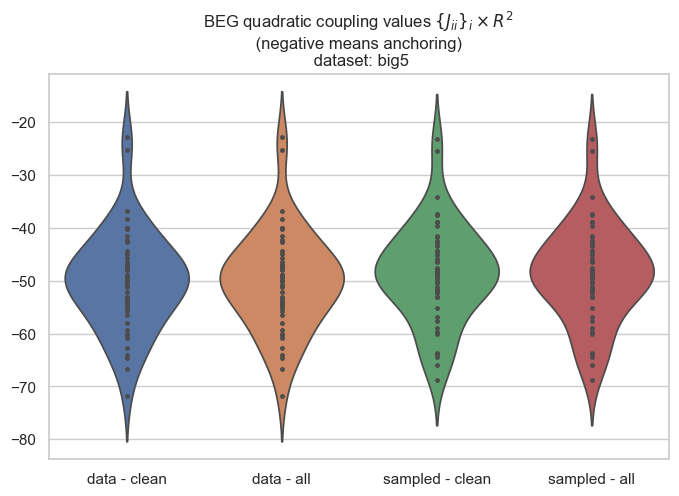

In [77]:
# Applica uno stile di default per lo sfondo
import seaborn as sns
sns.set_theme(style="whitegrid")
Jbeg_2_dict = {}
Jbeg_2_dict['data - clean'] = np.diag(JstarBEG_good)*R**2
Jbeg_2_dict['data - all'] = np.diag(JstarBEGCD)*R**2
Jbeg_2_dict['sampled - clean'] = np.diag(JstarBEG_samplegood)*R**2
Jbeg_2_dict['sampled - all'] = np.diag(JstarBEGCD_sample)*R**2

# Genera il grafico dal tuo dizionario
plt.figure(figsize=(8, 5))
plt.title('BEG quadratic coupling values $\{J_{ii}\}_{i}\\times R^2$ \n (negative means anchoring) \n dataset: ' + DATASET)
sns.violinplot(data=Jbeg_2_dict, inner="point")

# Mostra il risultato a schermo
plt.savefig(savepath + '/BEG_quadratic_couplings.pdf')
plt.show()


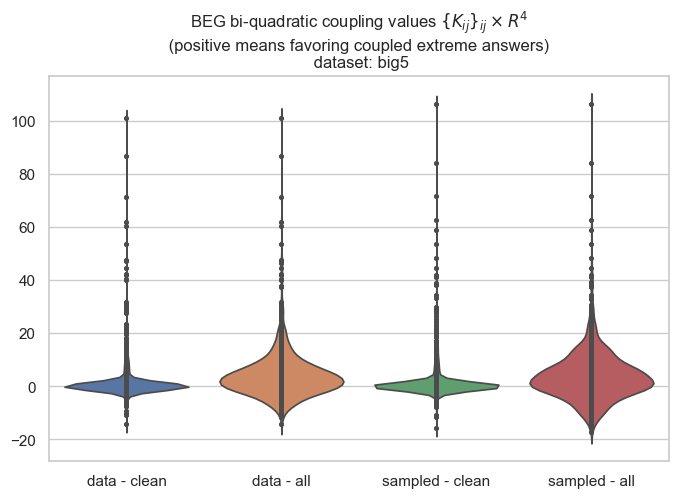

In [78]:
# Applica uno stile di default per lo sfondo
sns.set_theme(style="whitegrid")

Kbeg_dict = {}
Kbeg_dict['data - clean'] = KstarBEG_good.flatten()*R**4
Kbeg_dict['data - all'] = KstarBEGCD.flatten()*R**4
Kbeg_dict['sampled - clean'] = KstarBEG_samplegood.flatten()*R**4
Kbeg_dict['sampled - all'] = KstarBEGCD_sample.flatten()*R**4

# Genera il grafico dal tuo dizionario
plt.figure(figsize=(8, 5))
plt.title('BEG bi-quadratic coupling values $\{K_{ij}\}_{ij}\\times R^4$\n (positive means favoring coupled extreme answers) \n dataset: ' + DATASET)
sns.violinplot(data=Kbeg_dict, inner="point",rasterized=True)

# Mostra il risultato a schermo
plt.savefig(savepath + '/BEG_biquadratic_couplings.pdf')

plt.show()


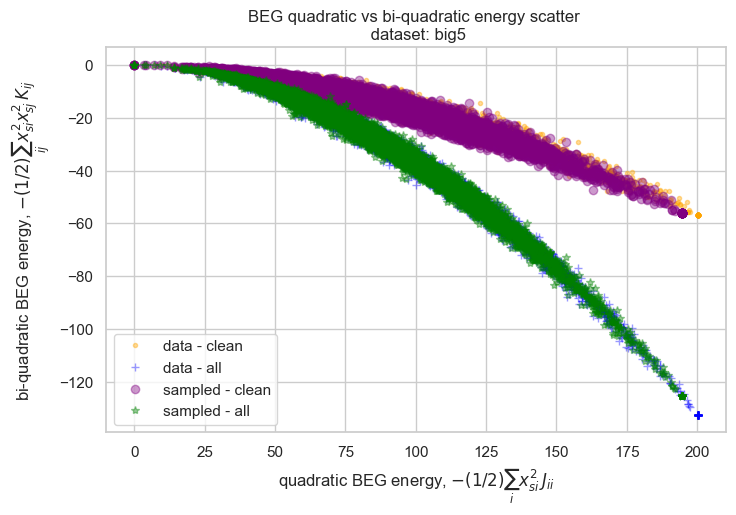

In [79]:
import itertools
marker = itertools.cycle(('.', '+', 'o', '*','^','>','s','x'))
color = itertools.cycle(('orange', 'blue', 'purple','green','red','brown','cyan','magenta'))

H2_BEG_dict = {}
H22_dict = {}

H2_BEG_dict['data - clean']     = -0.5*np.sum(X2*np.diag(JstarBEG_good),axis=1)
H22_dict['data - clean']        = - 0.5*np.einsum('ij,ji->i', X2 @ KstarBEG_good,X2.T)
H2_BEG_dict['data - all']       = - 0.5*np.sum(X2*np.diag(JstarBEGCD),axis=1)
H22_dict['data - all']          = - 0.5*np.einsum('ij,ji->i', X2 @ KstarBEGCD,X2.T)
H2_BEG_dict['sampled - clean']  = - 0.5*np.sum(X2*np.diag(JstarBEG_samplegood),axis=1)
H22_dict['sampled - clean']     = - 0.5*np.einsum('ij,ji->i', X2 @ KstarBEG_samplegood,X2.T)  
H2_BEG_dict['sampled - all']    = - 0.5*np.sum(X2*np.diag(JstarBEGCD_sample),axis=1)
H22_dict['sampled - all']       = - 0.5*np.einsum('ij,ji->i', X2 @ KstarBEGCD_sample,X2.T)

plt.figure(figsize=(8, 5))
plt.title('BEG quadratic vs bi-quadratic energy scatter \n dataset: ' + DATASET)
    
for lab in H2_BEG_dict.keys():
    plt.plot(H2_BEG_dict[lab],H22_dict[lab],label=lab,alpha=0.4,marker=next(marker),lw=0.,rasterized=True,color=next(color))

plt.legend()
plt.xlabel('quadratic BEG energy, $-(1/2)\\sum_i x_{si}^2\,J_{ii}$')
plt.ylabel('bi-quadratic BEG energy, $-(1/2)\\sum_{ij} x^2_{si}x^2_{sj}\,K_{ij}$')
plt.savefig(savepath + '/BEG_quadratic_biquadratic_energy_scatter.pdf',bbox_inches='tight')


(array([1, 2]), [Text(1, 0, 'J'), Text(2, 0, 'h')])

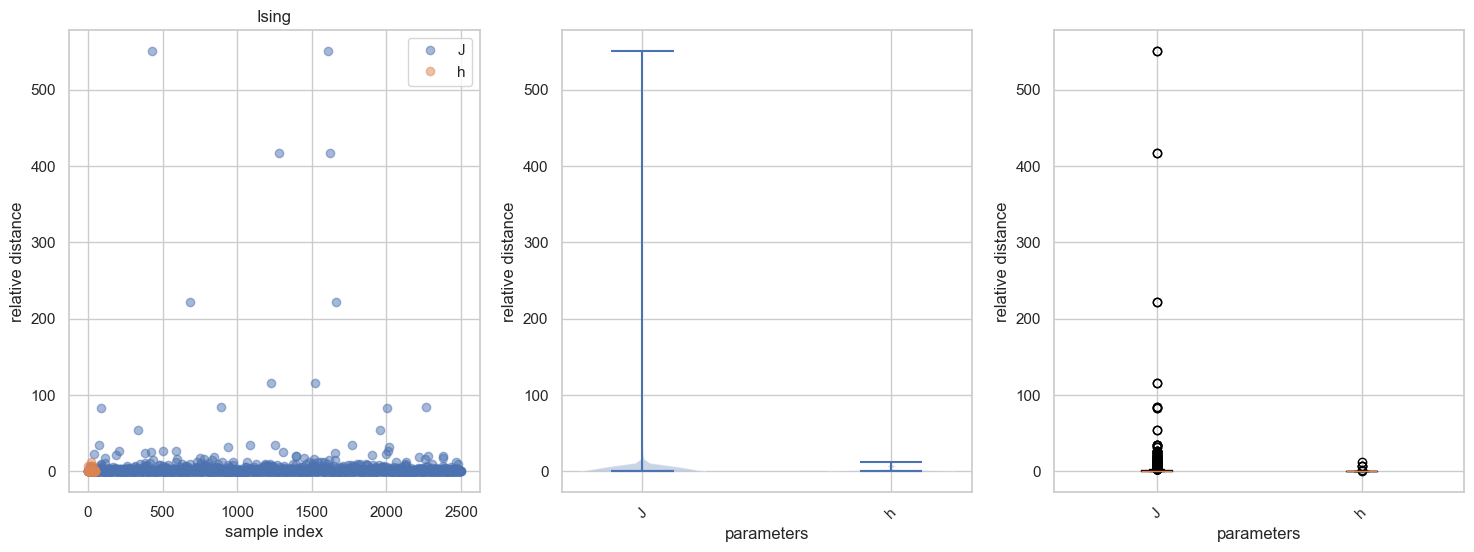

In [80]:
plt.figure(figsize=(18,6))
plt.subplot(1,3,1)
plt.plot(np.arange(len(d_J_Ising)), d_J_Ising, 'o', alpha=0.5, label='J')
plt.plot(np.arange(len(d_h_Ising)), d_h_Ising, 'o', alpha=0.5, label='h')
plt.xlabel('sample index')
plt.ylabel('relative distance')
plt.title('Ising')
plt.legend()

plt.subplot(1,3,2)
# plot the boxplots of the relative distances for J and h
parts = plt.violinplot([d_J_Ising, d_h_Ising], showmedians=True)
plt.xticks([1, 2], ['J', 'h'])
plt.xlabel('parameters')
plt.ylabel('relative distance')

plt.xticks(rotation=45)

plt.subplot(1,3,3)
plt.boxplot([d_J_Ising, d_h_Ising], labels=['J', 'h'])
plt.xlabel('parameters')
plt.ylabel('relative distance')
plt.xticks(rotation=45)

/var/folders/8q/wvskmyb14jlfp88877y4dh180000gn/T/ipykernel_5360/2360564325.py:7: RuntimeWarning: divide by zero encountered in log
  log_dJising = np.log(np.abs(d_J_Ising.flatten()))
/var/folders/8q/wvskmyb14jlfp88877y4dh180000gn/T/ipykernel_5360/2360564325.py:32: RuntimeWarning: divide by zero encountered in log
  log_dKbeg = np.log(np.abs(d_K_BEG.flatten()))


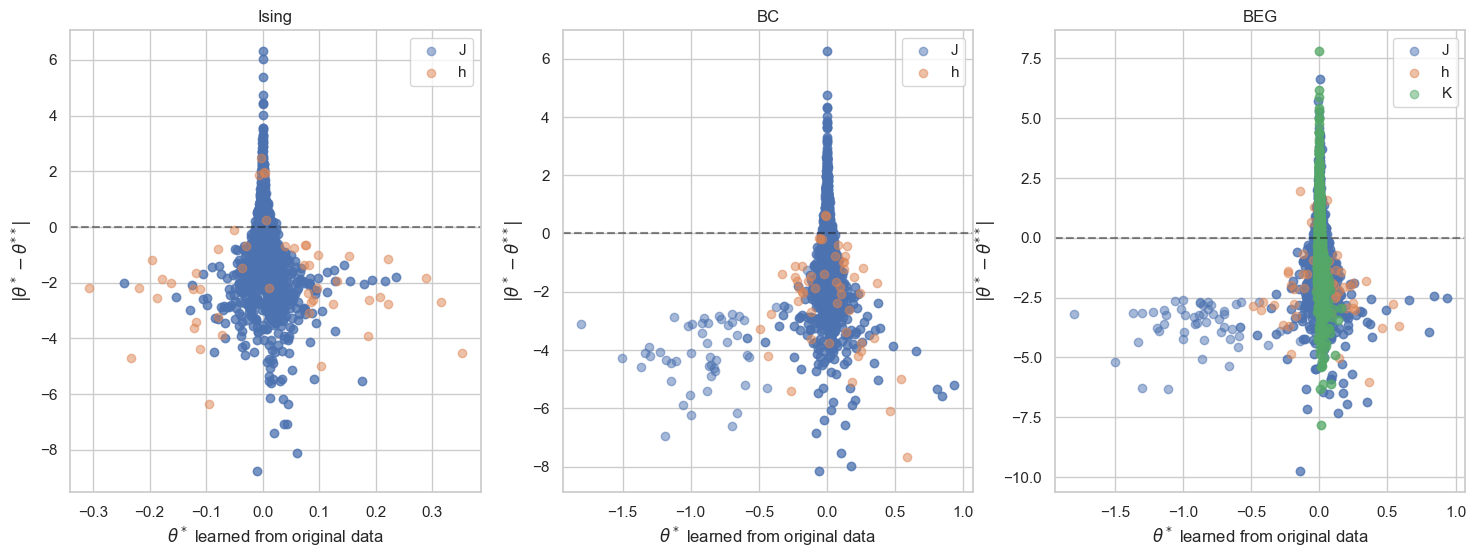

In [81]:
# scatter plots of the learned parameters from sampled data 
# vs learned from the original data

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
log_dJising = np.log(np.abs(d_J_Ising.flatten()))
log_dhising = np.log(np.abs(d_h_Ising.flatten()))
plt.scatter(JstarIsingCD.flatten(), log_dJising.flatten(), alpha=0.5, label='J')
plt.scatter(hstarIsingCD.flatten(), log_dhising.flatten(), alpha=0.5, label='h')
plt.axhline(0, color='k', linestyle='--', alpha=0.5)
#plt.yscale('log')
plt.xlabel(r'$\theta^*$ learned from original data')
plt.ylabel(r'$| \theta^* - \theta^{**} |$')
plt.title('Ising')
plt.legend()

plt.subplot(1,3,2)
log_dJbc = np.log(np.abs(d_J_BC.flatten()))
log_dhbc = np.log(np.abs(d_h_BC.flatten()))
plt.scatter(JstarBCCD.flatten(), log_dJbc.flatten(), alpha=0.5, label='J')
plt.scatter(hstarBCCD.flatten(), log_dhbc.flatten(), alpha=0.5, label='h')
plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.xlabel(r'$\theta^*$ learned from original data')
plt.ylabel(r'$| \theta^* - \theta^{**} |$')
plt.title('BC')
plt.legend()

plt.subplot(1,3,3)
log_dJbeg = np.log(np.abs(d_J_BEG.flatten()))
log_dhbeg = np.log(np.abs(d_h_BEG.flatten()))
log_dKbeg = np.log(np.abs(d_K_BEG.flatten()))
plt.scatter(JstarBCCD.flatten(), log_dJbeg.flatten(), alpha=0.5, label='J')
plt.scatter(hstarBCCD.flatten(), log_dhbeg.flatten(), alpha=0.5, label='h')
plt.scatter(KstarBEGCD.flatten(), log_dKbeg.flatten(), alpha=0.5, label='K')
plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.xlabel(r'$\theta^*$ learned from original data')
plt.ylabel(r'$| \theta^* - \theta^{**} |$')
plt.title('BEG')
plt.legend()
plt.savefig(os.path.join(savepath, 'parameter_stability_big5.png'), bbox_inches='tight')

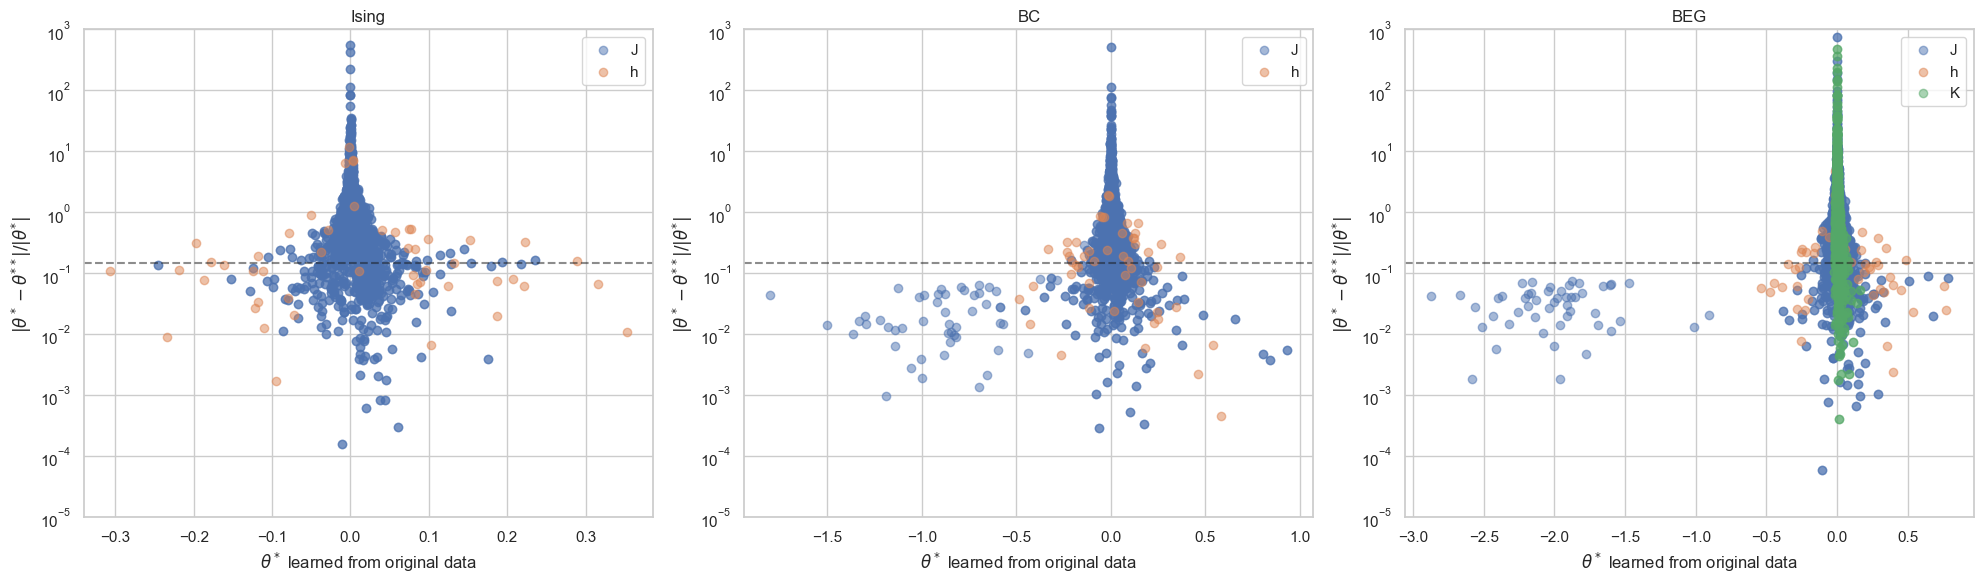

In [90]:
# scatter plots of the learned parameters from sampled data 
# vs learned from the original data

plt.figure(figsize=(20,6))

plt.subplot(1,3,1)
plt.scatter(JstarIsingCD.flatten(), d_J_Ising.flatten(), alpha=0.5, label='J')
plt.scatter(hstarIsingCD.flatten(), d_h_Ising.flatten(), alpha=0.5, label='h')
plt.axhline(threshold, color='k', linestyle='--', alpha=0.5)
plt.yscale('symlog', linthresh=1e-5)  
plt.ylim(1e-5, 1e3)
plt.xlabel(r'$\theta^*$ learned from original data')
plt.ylabel(r'$| \theta^* - \theta^{**} |/ |\theta^{*}|$')
plt.title('Ising')
plt.legend()

plt.subplot(1,3,2)
plt.scatter(JstarBCCD.flatten(), d_J_BC.flatten(), alpha=0.5, label='J')
plt.scatter(hstarBCCD.flatten(), d_h_BC.flatten(), alpha=0.5, label='h')
plt.axhline(threshold, color='k', linestyle='--', alpha=0.5)
plt.yscale('symlog', linthresh=1e-5)  
plt.ylim(1e-5, 1e3)
plt.xlabel(r'$\theta^*$ learned from original data')
plt.ylabel(r'$| \theta^* - \theta^{**} |/ |\theta^{*}|$')
plt.title('BC')
plt.legend()

plt.subplot(1,3,3)
plt.scatter(JstarBEGCD.flatten(), d_J_BEG.flatten(), alpha=0.5, label='J')
plt.scatter(hstarBEGCD.flatten(), d_h_BEG.flatten(), alpha=0.5, label='h')
plt.scatter(KstarBEGCD.flatten(), d_K_BEG.flatten(), alpha=0.5, label='K')
plt.axhline(threshold, color='k', linestyle='--', alpha=0.5)
plt.yscale('symlog', linthresh=1e-5)  
plt.ylim(1e-5, 1e3)
plt.xlabel(r'$\theta^*$ learned from original data')
plt.ylabel(r'$| \theta^* - \theta^{**} |/ |\theta^{*}|$')
plt.title('BEG')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(savepath, 'parameter_stability_big5.png'), bbox_inches='tight')

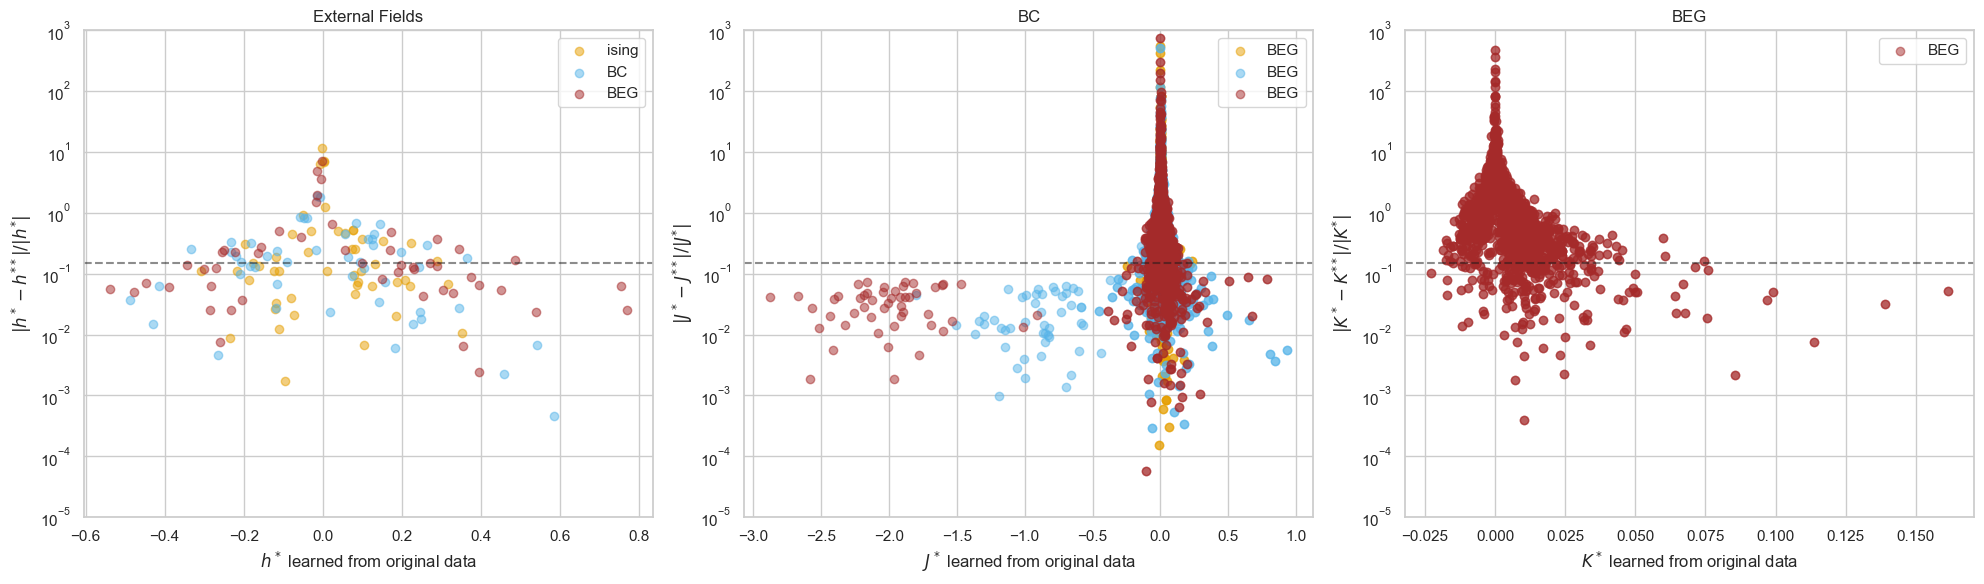

In [93]:
# scatter plots of the learned parameters from sampled data 
# vs learned from the original data

plt.figure(figsize=(20,6))

plt.subplot(1,3,1)
plt.scatter(hstarIsingCD.flatten(), d_h_Ising.flatten(), c=COLORS['ising'], alpha=0.5, label='ising')
plt.scatter(hstarBCCD.flatten(), d_h_BC.flatten(), c=COLORS['bc'], alpha=0.5, label='BC')
plt.scatter(hstarBEGCD.flatten(), d_h_BEG.flatten(), c=COLORS['beg'], alpha=0.5, label='BEG')
plt.axhline(threshold, color='k', linestyle='--', alpha=0.5)
plt.yscale('symlog', linthresh=1e-5)  
plt.ylim(1e-5, 1e3)
plt.xlabel(r'$ h^*$ learned from original data')
plt.ylabel(r'$| h^* - h^{**} | / |h^{*}|$')
plt.title('External Fields')
plt.legend()

plt.subplot(1,3,2)
plt.scatter(JstarIsingCD.flatten(), d_J_Ising.flatten(), c=COLORS['ising'], alpha=0.5, label='BEG')
plt.scatter(JstarBCCD.flatten(), d_J_BC.flatten(), c=COLORS['bc'], alpha=0.5, label='BEG')
plt.scatter(JstarBEGCD.flatten(), d_J_BEG.flatten(), c=COLORS['beg'], alpha=0.5, label='BEG')
plt.axhline(threshold, color='k', linestyle='--', alpha=0.5)
plt.yscale('symlog', linthresh=1e-5)  
plt.ylim(1e-5, 1e3)
plt.xlabel(r'$J^*$ learned from original data')
plt.ylabel(r'$| J^* - J^{**} | / |J^{*}|$')
plt.title('BC')
plt.legend()

plt.subplot(1,3,3)
plt.scatter(KstarBEGCD.flatten(), d_K_BEG.flatten(), c=COLORS['beg'], alpha=0.5, label='BEG')
plt.axhline(threshold, color='k', linestyle='--', alpha=0.5)
plt.yscale('symlog', linthresh=1e-5)  
plt.ylim(1e-5, 1e3)
plt.xlabel(r'$K^*$ learned from original data')
plt.ylabel(r'$| K^* - K^{**} | / |K^{*}|$')
plt.title('BEG')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(savepath, 'parameter_stability_big5_2nd.png'), bbox_inches='tight')

## Plot the heatmaps of the parameters

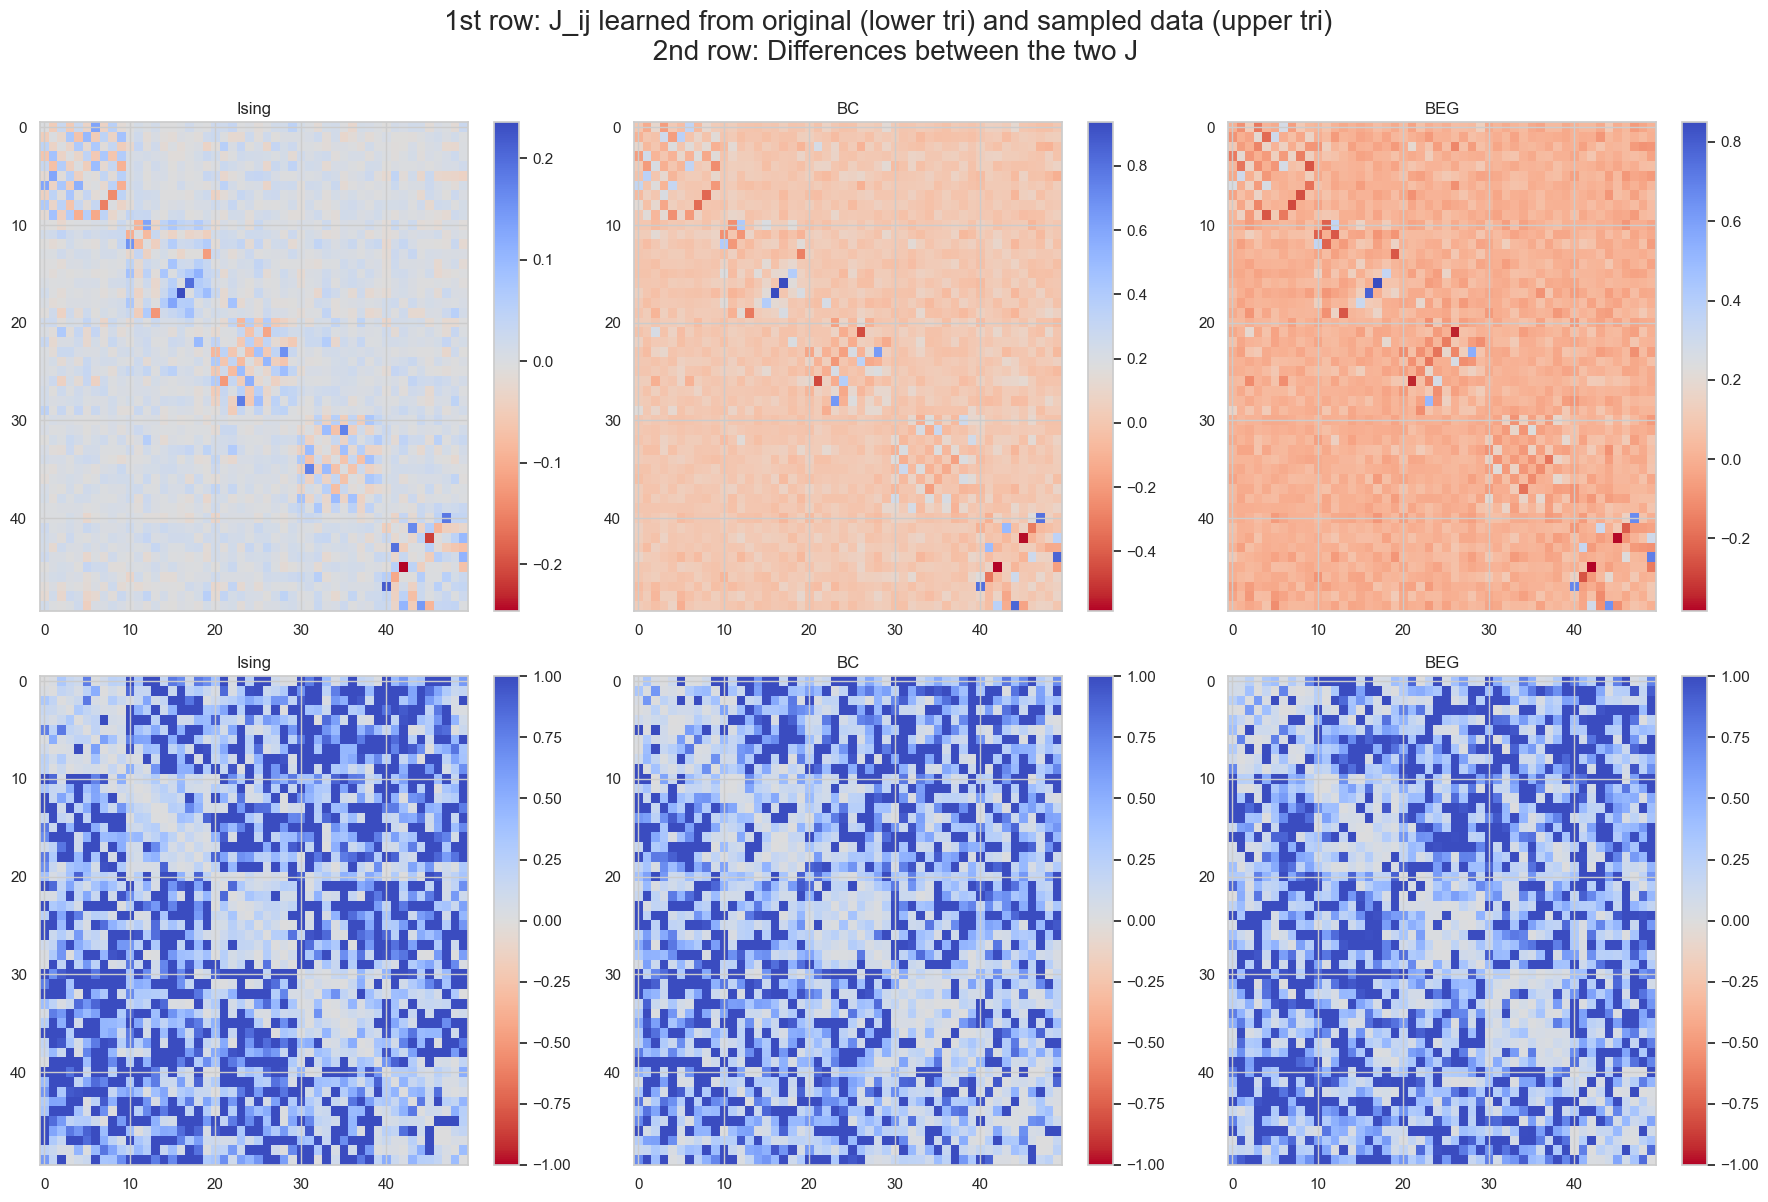

In [84]:
# plot heatmaps of the learned parameters from sampled data vs learned from the original data

plt.figure(figsize=(18,12))

plt.subplot(2,3,1)
# compute the triangular part of the J matrix for Ising model
JstarIsingCD_sample_tri = np.triu(JstarIsingCD_sample, k=1) # lower triangular part of the matrix
JstarIsingCD_tri = np.triu(JstarIsingCD, k=1).T # upper triangular part of the matrix
J_combined_ising = JstarIsingCD_sample_tri + JstarIsingCD_tri
plt.imshow(J_combined_ising, cmap='coolwarm_r', aspect='auto')
plt.colorbar()
plt.title('Ising')

plt.subplot(2,3,2)
# compute the triangular part of the J matrix for BC model
JstarBCCD_sample_tri = np.triu(JstarBCCD_sample, k=1) # lower triangular part of the matrix
JstarBCCD_tri = np.triu(JstarBCCD, k=1).T # upper triangular part of the matrix
J_combined_bc = JstarBCCD_sample_tri + JstarBCCD_tri
plt.imshow(J_combined_bc, cmap='coolwarm_r', aspect='auto')
plt.colorbar()
plt.title('BC')

plt.subplot(2,3,3)
# compute the triangular part of the J matrix for BEG model
JstarBEGCD_sample_tri = np.triu(JstarBEGCD_sample, k=1) # lower triangular part of the matrix
JstarBEGCD_tri = np.triu(JstarBEGCD, k=1).T # upper triangular part of the matrix
J_combined_beg = JstarBEGCD_sample_tri + JstarBEGCD_tri
plt.imshow(J_combined_beg, cmap='coolwarm_r', aspect='auto')
plt.colorbar()
plt.title('BEG')

# plot heatmaps of the difference between learned parameters from sampled data vs learned from the original data
vmin = -1
vmax = 1

plt.subplot(2,3,4)
plt.imshow(d_J_Ising.reshape(JstarIsingCD.shape), cmap='coolwarm_r', aspect='auto', vmin = vmin, vmax = vmax)
plt.colorbar()
plt.title('Ising')

plt.subplot(2,3,5)
plt.imshow(d_J_BC.reshape(JstarBCCD.shape), cmap='coolwarm_r', aspect='auto', vmin = vmin, vmax = vmax)
plt.colorbar()
plt.title('BC')

plt.subplot(2,3,6)
plt.imshow(d_J_BEG.reshape(JstarBEGCD.shape), cmap='coolwarm_r', aspect='auto', vmin = vmin, vmax = vmax)
plt.colorbar()
plt.title('BEG')

plt.suptitle('1st row: J_ij learned from original (lower tri) and sampled data (upper tri) \n 2nd row: Differences between the two J', fontsize=20, y=1.0)
plt.tight_layout()

plt.show()

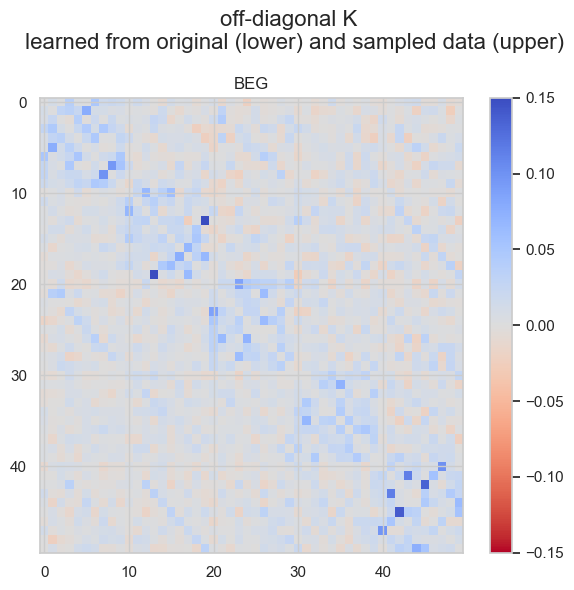

In [85]:
# plot heatmaps of the learned parameters from sampled data vs learned from the original data

plt.figure(figsize=(6,6))
# compute the triangular part of the K matrix for BEG model
KstarBEGCD_sample_tri = np.triu(KstarBEGCD_sample, k=1) # lower triangular part of the matrix
KstarBEGCD_tri = np.triu(KstarBEGCD, k=1).T # upper triangular part of the matrix
K_combined_beg = KstarBEGCD_sample_tri + KstarBEGCD_tri
plt.imshow(K_combined_beg, cmap='coolwarm_r', aspect='auto', vmin = -0.15, vmax = 0.15)
plt.colorbar()
plt.title('BEG')

plt.suptitle('off-diagonal K \n learned from original (lower) and sampled data (upper)', fontsize=16)
plt.tight_layout()

plt.show()

In [86]:
# plot the fields and the diagonal